In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("former_names.csv")

print(df.head())
print(df.info())

          current                former  start_date    end_date
0           Benin               Dahomey  1959-11-08  1975-11-30
1    Burkina Faso           Upper Volta  1960-04-14  1984-08-04
2         Curaçao  Netherlands Antilles  1957-03-03  2010-10-10
3  Czechoslovakia               Bohemia  1903-04-05  1919-01-01
4  Czechoslovakia   Bohemia and Moravia  1939-01-01  1945-05-01
<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   current     36 non-null     str  
 1   former      36 non-null     str  
 2   start_date  36 non-null     str  
 3   end_date    36 non-null     str  
dtypes: str(4)
memory usage: 2.7 KB
None


In [4]:
for col in df.select_dtypes(include=["string", "object"]).columns:
    if col != "target":
        df[col] = df[col].astype("string")
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

In [7]:
df.columns = df.columns.str.strip()



In [8]:
for col in df.columns:
    print(col)

current
former
start_date
end_date


In [9]:
df.head()

,current,former,start_date,end_date
0,0,9,24,20
1,1,32,25,24
2,2,20,21,33
3,3,1,1,0
4,3,2,9,3


In [10]:
df.columns.tolist()

['current', 'former', 'start_date', 'end_date']

In [12]:
print(df.columns)

Index(['current', 'former', 'start_date', 'end_date'], dtype='str')


In [13]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['current', 'former', 'start_date', 'end_date'], dtype='str')


In [14]:
df.head()

,current,former,start_date,end_date
0,0,9,24,20
1,1,32,25,24
2,2,20,21,33
3,3,1,1,0
4,3,2,9,3


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   current     36 non-null     int64
 1   former      36 non-null     int64
 2   start_date  36 non-null     int64
 3   end_date    36 non-null     int64
dtypes: int64(4)
memory usage: 1.3 KB


In [19]:
df.head()
df.columns

Index(['current', 'former', 'start_date', 'end_date'], dtype='str')

In [23]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [27]:
print(y.head())
print(y.nunique())

0    20
1    24
2    33
3     0
4     3
Name: end_date, dtype: int64
36


In [28]:
print(len(set(y)))
print(len(y))

36
36


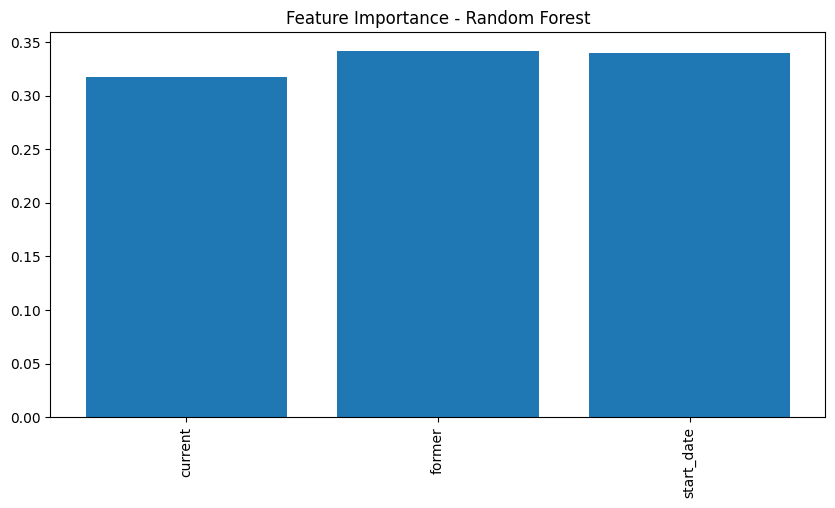

In [29]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X.columns

plt.figure(figsize=(10,5))
plt.bar(features, importances)
plt.xticks(rotation=90)
plt.title("Feature Importance - Random Forest")
plt.show()